In [1]:
# Bag of N grams tutorial

In [2]:
# Let's first understand how to generate n-grams using CountVectorizer

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

In [4]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

In [5]:
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

In [6]:
# We will now take a simple collection of text documents, preprocess them to 
# remove stop words, lemmatize etc and then generate bag of 1 grams and 2 grams from it

In [7]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [8]:
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens) 

In [9]:
# so int the preprocess funtion, we filtered stop words, punctuations and did lemmatization.
preprocess("Thor ate pizza")

'thor eat pizza'

In [10]:
preprocess("Loki is eating pizza")

'Loki eat pizza'

In [11]:
corpus_processed = [
    preprocess(text) for text in corpus # iterate through all words in preprocessed text
]
corpus_processed

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [12]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [13]:
# Now generate bag of n gram vector for few sample documents
# this is done because we need vectors to process, not the above dictionary.

In [14]:
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]], dtype=int64)

In [15]:
# Let's take a document that has out of vocabulary (OOV) term and see how bag of ngram generates vector out of it.
# Hulk is entirely a new vocabilary.

In [16]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]], dtype=int64)

In [17]:
# News Category Classification Problem

In [18]:
'''
This is a real problem. Here we want to do a news category classification. 
We will use bag of n-grams and training a machine learning model that can categorize any news into one 
of the following categories,

1. BUSINESS
1. SPORTS
1. CRIME
1. SCIENCE
'''

'\nThis is a real problem. Here we want to do a news category classification. \nWe will use bag of n-grams and training a machine learning model that can categorize any news into one \nof the following categories,\n\n1. BUSINESS\n1. SPORTS\n1. CRIME\n1. SCIENCE\n'

In [19]:
'''
- This data consists of two columns.
        - Text
        - Category
- Text is a news article
- Category can be one of these 4: 'BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE', to keep things simple I trimmed additional categories from the original dataset
'''

"\n- This data consists of two columns.\n        - Text\n        - Category\n- Text is a news article\n- Category can be one of these 4: 'BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE', to keep things simple I trimmed additional categories from the original dataset\n"

In [20]:
import pandas as pd

df = pd.read_json('news_dataset.json')
print(df.shape)

df.head()

(12695, 2)


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [21]:
df.category.value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [22]:
'''
Handle class imbalance:

As you can see above, SCIENCE category has almost 1/3rd data samples compared to BUSINESS and SPORTS categories. 
I initially trained a model without handling the imbalanced I saw a lower f1-score for SCIENCE category. 
Hence we need to address this imbalanced class. 

we will use **undersampling** technique here. 
In undersampling, we take a minor class and sample those many samples from other classes, 
this means we are not utilizing all the data samples for training and in ML world - Not using all the data for 
training is considered a SIN! 😵 In real life, you are advised to use a technique such as SMOTE so that you can 
utilize all of your dataset for the training but since this we are looking more about bag of n-grams then class imbalance itself, I'd go with a simple technique of undersampling. 
'''

"\nHandle class imbalance:\n\nAs you can see above, SCIENCE category has almost 1/3rd data samples compared to BUSINESS and SPORTS categories. \nI initially trained a model without handling the imbalanced I saw a lower f1-score for SCIENCE category. \nHence we need to address this imbalanced class. \n\nwe will use **undersampling** technique here. \nIn undersampling, we take a minor class and sample those many samples from other classes, \nthis means we are not utilizing all the data samples for training and in ML world - Not using all the data for \ntraining is considered a SIN! 😵 In real life, you are advised to use a technique such as SMOTE so that you can \nutilize all of your dataset for the training but since this we are looking more about bag of n-grams then class imbalance itself, I'd go with a simple technique of undersampling. \n"

In [23]:
min_samples = 1381 # we have these many SCIENCE articles and SCIENCE is our minority class


df_business = df[df.category=="BUSINESS"].sample(min_samples, random_state=2022) # take random samples same as minority class and create a new column df_business
df_sports = df[df.category=="SPORTS"].sample(min_samples, random_state=2022)
df_crime = df[df.category=="CRIME"].sample(min_samples, random_state=2022)
df_science = df[df.category=="SCIENCE"].sample(min_samples, random_state=2022)

In [24]:
df_balanced = pd.concat([df_business,df_sports,df_crime,df_science],axis=0) # combining four newly created categories.
df_balanced.category.value_counts()

category
BUSINESS    1381
SPORTS      1381
CRIME       1381
SCIENCE     1381
Name: count, dtype: int64

In [25]:
# Convert text category to a number

In [26]:
# just mapping numbers to categories.

target = {'BUSINESS': 0, 'SPORTS': 1, 'CRIME': 2, 'SCIENCE': 3}

df_balanced['category_num'] = df_balanced['category'].map(target)

In [27]:
df_balanced.head()

,text,category,category_num
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0
502,How to Market Your Business While Traveling th...,BUSINESS,0
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0


In [28]:
# Build a model with original text (no pre processing)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.text, # X
    df_balanced.category_num, # y
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df_balanced.category_num
)

In [30]:
print(X_train.shape)
X_train.head()

(4419,)


7589     Ovulating Women Prefer Images of Penetration O...
10442    Scientists Discover Spooky Influence On Baby N...
8792     Olympic Race Walker Steps Up To Propose To His...
1733     Beloved Bipedal Bear Named Pedals Believed Kil...
2526     Elizabeth Smart Gave Birth To Baby Girl, Fathe...
Name: text, dtype: object

In [31]:
y_train.value_counts()

category_num
3    1105
2    1105
0    1105
1    1104
Name: count, dtype: int64

In [32]:
y_test.value_counts()

category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64

In [33]:
# Attempt 1 : Use 1-gram which is nothing but a Bag Of Words (BOW) model

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_bow', CountVectorizer(ngram_range = (1, 1))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train) # X_train, y_train are already imbalanced handled.


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.87      0.81       276
           1       0.93      0.80      0.86       277
           2       0.83      0.90      0.86       276
           3       0.90      0.80      0.85       276

    accuracy                           0.84      1105
   macro avg       0.85      0.84      0.84      1105
weighted avg       0.85      0.84      0.84      1105



In [35]:
X_test[:5]

3716     African Nation Slaps Exxon With Fine Nearly 7 ...
608      These Cringe-Worthy Stories Show It Can Be Har...
11172    LISTEN: The Accidental Discovery That Proved T...
1346     Build Loyalty -- The Cost -- $00.00 Remember y...
1356     Man Killed By Michigan Police Wasn't Targeting...
Name: text, dtype: object

In [36]:
'''
- BUSINESS: 0
- SPORTS: 1
- CRIME: 2
- SCIENCE: 3
'''

'\n- BUSINESS: 0\n- SPORTS: 1\n- CRIME: 2\n- SCIENCE: 3\n'

In [37]:
y_pred[:5]

array([0, 3, 3, 0, 2], dtype=int64)

In [38]:
y_test[:5] # here y_pred and y_test are same, which means model didnt mage any mistakes.
# y_test is the truth, and y_pred is derived from x_test.

3716     0
608      3
11172    3
1346     0
1356     2
Name: category_num, dtype: int64

In [39]:
# Attempt 2 : Use 1-gram and bigrams

In [40]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_2_gram', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.90      0.78       276
           1       0.95      0.74      0.83       277
           2       0.82      0.88      0.85       276
           3       0.92      0.78      0.84       276

    accuracy                           0.82      1105
   macro avg       0.85      0.82      0.83      1105
weighted avg       0.85      0.82      0.83      1105



In [41]:
# Attempt 3 : Use 1-gram to trigrams

In [42]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_3_grams', CountVectorizer(ngram_range = (1, 3))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.91      0.77       276
           1       0.96      0.73      0.83       277
           2       0.83      0.87      0.85       276
           3       0.93      0.76      0.83       276

    accuracy                           0.82      1105
   macro avg       0.84      0.82      0.82      1105
weighted avg       0.84      0.82      0.82      1105



In [43]:
# # Use text pre-processing to remove stop words, punctuations and apply lemmatization

In [44]:
'''You may wonder, we have not done any text-processing yet to remove stop words, punctuations, apply lemmatization etc. 
Well we wanted to train the model without any preprocessing first and check the performance. 
Now we will re-do same thing but with preprocessing of text'''

'You may wonder, we have not done any text-processing yet to remove stop words, punctuations, apply lemmatization etc. \nWell we wanted to train the model without any preprocessing first and check the performance. \nNow we will re-do same thing but with preprocessing of text'

In [45]:
df_balanced['preprocessed_txt'] = df_balanced['text'].apply(preprocess)

In [46]:
df_balanced.head()

,text,category,category_num,preprocessed_txt
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0,GCC Business leader remain confident Face Regi...
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0,Honest Review Employees wake morning love impo...
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0,Mike McDerment CEO FreshBooks Talks give build...
502,How to Market Your Business While Traveling th...,BUSINESS,0,market business travel World recently amazing ...
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0,leverage intuition decision making feel safe r...


In [47]:
# Build a model with pre processed text

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.preprocessed_txt, 
    df_balanced.category_num, 
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df_balanced.category_num
)

In [49]:
print(X_train.shape)
X_train.head()

(4419,)


7589     ovulate Women prefer Images Penetration Images...
10442     scientist discover Spooky Influence Baby Choices
8792     Olympic Race Walker step Propose boyfriend Rio...
1733     Beloved Bipedal Bear name Pedals believe kill ...
2526       Elizabeth Smart give Birth Baby Girl Father say
Name: preprocessed_txt, dtype: object

In [50]:
y_train.value_counts()

category_num
3    1105
2    1105
0    1105
1    1104
Name: count, dtype: int64

In [51]:
y_test.value_counts()

category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64

In [52]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
    ('Multi NB', MultinomialNB())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       276
           1       0.94      0.81      0.87       277
           2       0.82      0.91      0.86       276
           3       0.91      0.82      0.86       276

    accuracy                           0.85      1105
   macro avg       0.86      0.85      0.85      1105
weighted avg       0.86      0.85      0.85      1105



In [53]:
'''
If you compare above classification report for (1,2) gram with the one from unprocessed text,
you will find some improvement in the model that uses preprocessed cleaned up text. 
Hence we can conclude that for this particular problem using preprocessing 
(removing stop words, lemmatization etc...) is improving the performance of the model
'''

'\nIf you compare above classification report for (1,2) gram with the one from unprocessed text,\nyou will find some improvement in the model that uses preprocessed cleaned up text. \nHence we can conclude that for this particular problem using preprocessing \n(removing stop words, lemmatization etc...) is improving the performance of the model\n'

In [54]:
# Plot confusion matrix

In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[242,   7,  16,  11],
       [ 13, 225,  33,   6],
       [ 17,   2, 252,   5],
       [ 38,   6,   7, 225]], dtype=int64)

Text(95.72222222222221, 0.5, 'Truth')

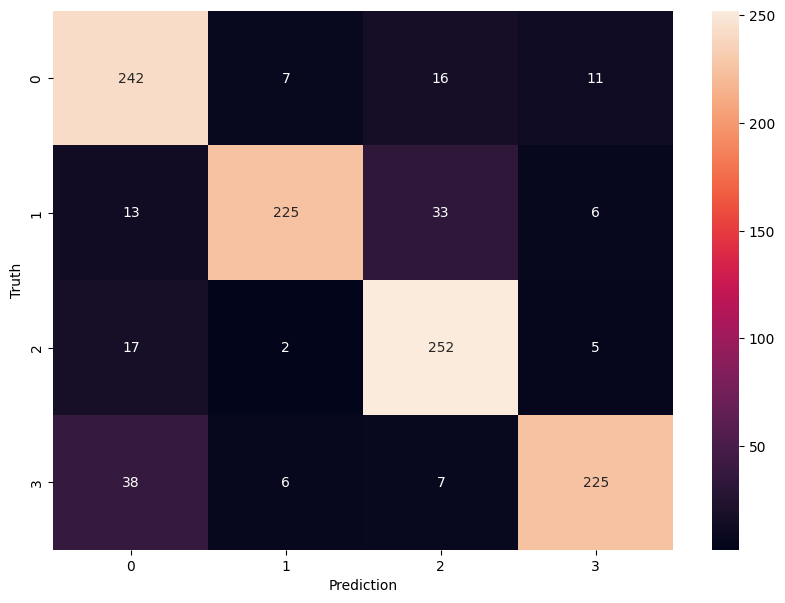

In [56]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')